<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="https://campusvirtual.urv.cat/pluginfile.php/1/core_admin/logocompact/300x300/1767733831/logoURVppd.png", align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">2025-2026 SCIENTIFIC PROGRAMMING (17715101)</p>
<p style="margin: 0; text-align:right;">MD Health Data Science / Biomedical Data Science</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>

# Exploratory Data Analysis

In [5]:
### Load relevant packages

import pandas                  as pd
import numpy                   as np
import matplotlib.pyplot       as plt
import seaborn                 as sns

from sklearn.preprocessing import StandardScaler

# Adding src to the current path
import sys
sys.path.append('..')

from src.preprocessing.rename import rename_columns, parse_column

# This statement allow to display plots without asking to 
%matplotlib inline

# Set style for plots
plt.style.use('ggplot')

In [6]:
#Load dataset
df = pd.read_csv('../data/breast_cancer_original.csv', dtype = { 'diagnosis': 'category'}) # indicate that diagnosis is categorical
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [7]:
#Shape of the dataset
df.shape

(569, 31)

In [8]:
#Checking data types and columns names
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   mean radius              569 non-null    float64 
 1   mean texture             569 non-null    float64 
 2   mean perimeter           569 non-null    float64 
 3   mean area                569 non-null    float64 
 4   mean smoothness          569 non-null    float64 
 5   mean compactness         569 non-null    float64 
 6   mean concavity           569 non-null    float64 
 7   mean concave points      569 non-null    float64 
 8   mean symmetry            569 non-null    float64 
 9   mean fractal dimension   569 non-null    float64 
 10  radius error             569 non-null    float64 
 11  texture error            569 non-null    float64 
 12  perimeter error          569 non-null    float64 
 13  area error               569 non-null    float64 
 14  smoothness

In [9]:
#Check if they have spaces at the end or beginning of the names
list(df.columns.values)

['mean radius',
 'mean texture',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension',
 'diagnosis']

We can see that the column names contain blank spaces. Let's rename them to make them easier to work with later.

In [10]:
dict_names = {col: parse_column(col) for col in df.columns}
renamed_df = rename_columns(df, dict_names)

In [11]:
list(renamed_df.columns.values)

['mean_radius',
 'mean_texture',
 'mean_perimeter',
 'mean_area',
 'mean_smoothness',
 'mean_compactness',
 'mean_concavity',
 'mean_concave_points',
 'mean_symmetry',
 'mean_fractal_dimension',
 'radius_error',
 'texture_error',
 'perimeter_error',
 'area_error',
 'smoothness_error',
 'compactness_error',
 'concavity_error',
 'concave_points_error',
 'symmetry_error',
 'fractal_dimension_error',
 'worst_radius',
 'worst_texture',
 'worst_perimeter',
 'worst_area',
 'worst_smoothness',
 'worst_compactness',
 'worst_concavity',
 'worst_concave_points',
 'worst_symmetry',
 'worst_fractal_dimension',
 'diagnosis']

The dataset is supposed to contain no null values, but let's verify it.

In [12]:
renamed_df.isna().sum()

mean_radius                0
mean_texture               0
mean_perimeter             0
mean_area                  0
mean_smoothness            0
mean_compactness           0
mean_concavity             0
mean_concave_points        0
mean_symmetry              0
mean_fractal_dimension     0
radius_error               0
texture_error              0
perimeter_error            0
area_error                 0
smoothness_error           0
compactness_error          0
concavity_error            0
concave_points_error       0
symmetry_error             0
fractal_dimension_error    0
worst_radius               0
worst_texture              0
worst_perimeter            0
worst_area                 0
worst_smoothness           0
worst_compactness          0
worst_concavity            0
worst_concave_points       0
worst_symmetry             0
worst_fractal_dimension    0
diagnosis                  0
dtype: int64

In [13]:
#Basic statistics
renamed_df.describe()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [14]:
#Check class distribution
renamed_df['diagnosis'].value_counts()

diagnosis
1    357
0    212
Name: count, dtype: int64

Let's check whether the dataset is balanced. To do that, we'll look at the distribution of the target variable.

d:\projects\venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\projects\venv\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


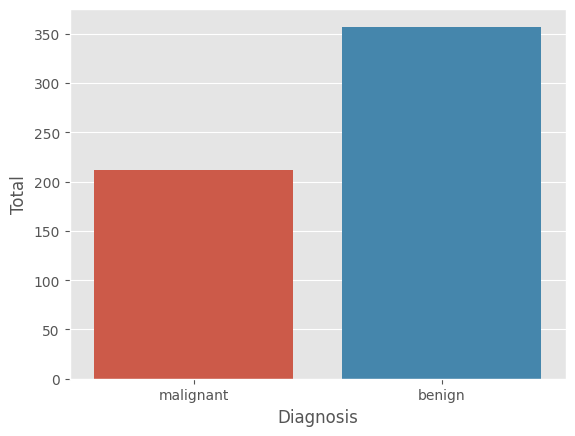

In [15]:
renamed_df["diagnosis_label"] = renamed_df["diagnosis"].map(lambda x: "benign" if x=="1" else "malignant") # Using quotion marks because diagnosis is categorical
sns.countplot(data=renamed_df, x="diagnosis_label")
plt.xlabel("Diagnosis")
plt.ylabel("Total")
plt.show()

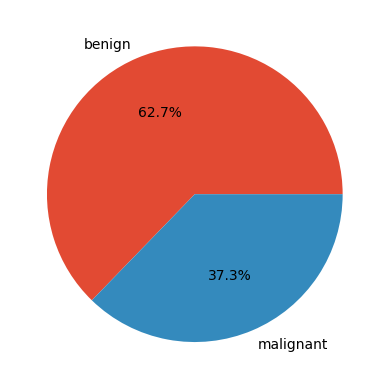

In [16]:
#Print the percentages of each class
value_counts = renamed_df["diagnosis_label"].value_counts()

plt.pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%')
plt.show()

We can see that the dataset is not balanced, since there are more benign cases than malignant ones.

We proceed to check for outliers in the numerical variables using boxplots.

In [17]:
# We get only the numerical columns
numerical_df = renamed_df.select_dtypes(include=[np.number])

We have 30 numerical variables in total. Let's take a look by plotting all the boxplots together.

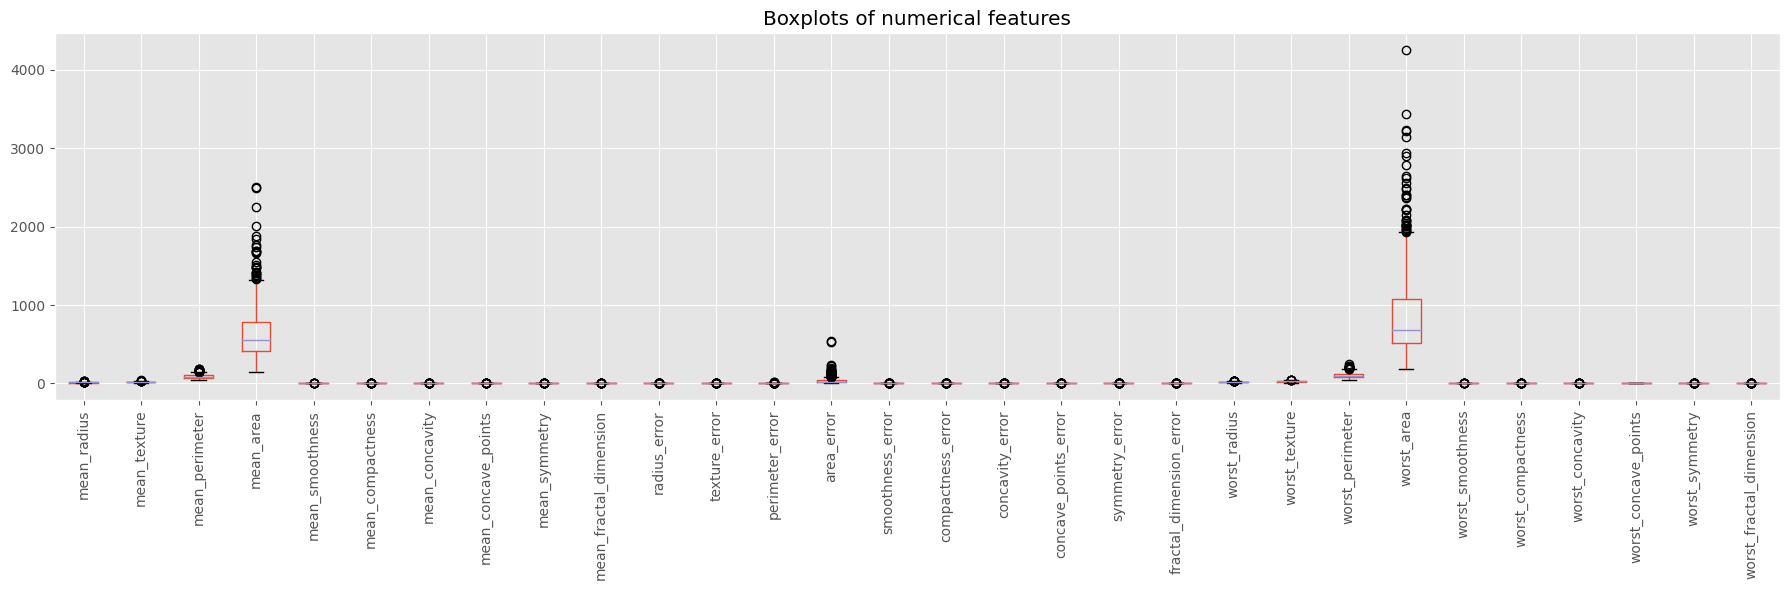

In [18]:
plt.figure(figsize=(18, 6))
numerical_df.boxplot(rot=90)
plt.title("Boxplots of numerical features")
plt.tight_layout()
plt.show()

Since the variables have different scales, it's hard to see the outliers in some cases. We can observe that many variables contain outliers. To make them easier to visualize, we'll scale the numerical variables using sklearn's StandardScaler, which centers them at the mean and scales them to a standard deviation of 1.

In [28]:
scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(numerical_df)

numerical_scaled_df = pd.DataFrame(
    numerical_scaled,
    columns=numerical_df.columns,
    index=numerical_df.index
)

scaled_df = pd.concat([renamed_df[['diagnosis', 'diagnosis_label']], numerical_scaled_df], axis=1)
scaled_df.to_csv('../data/breast_cancer_scaled.csv', index=False)

d:\projects\venv\lib\site-packages\sklearn\utils\validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
d:\projects\venv\lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
d:\projects\venv\lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
d:\projects\venv\lib\site-packages\sklearn\utils\validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") a

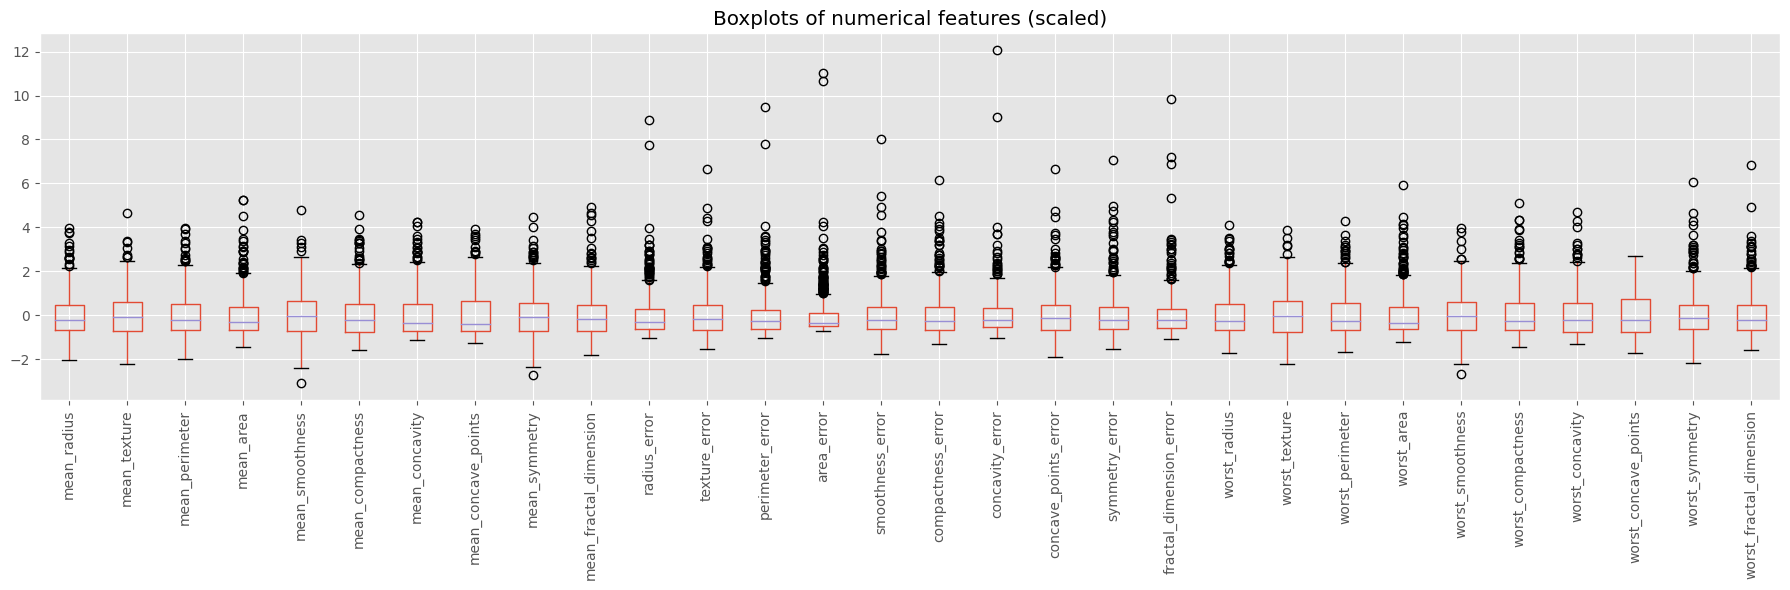

In [20]:
plt.figure(figsize=(18, 6))
numerical_scaled_df.boxplot(rot=90)
plt.title("Boxplots of numerical features (scaled)")
plt.tight_layout()
plt.show()

Let's look at the correlations between the numerical variables, in case we need to remove any variables that are highly correlated with others.

In [21]:
# Calculate correlation matrix
corr_matrix = numerical_df.corr()
corr_matrix

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
mean_radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
mean_texture,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
mean_perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
mean_area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
mean_smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
mean_compactness,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
mean_concavity,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
mean_concave_points,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
mean_symmetry,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
mean_fractal_dimension,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.253691,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297


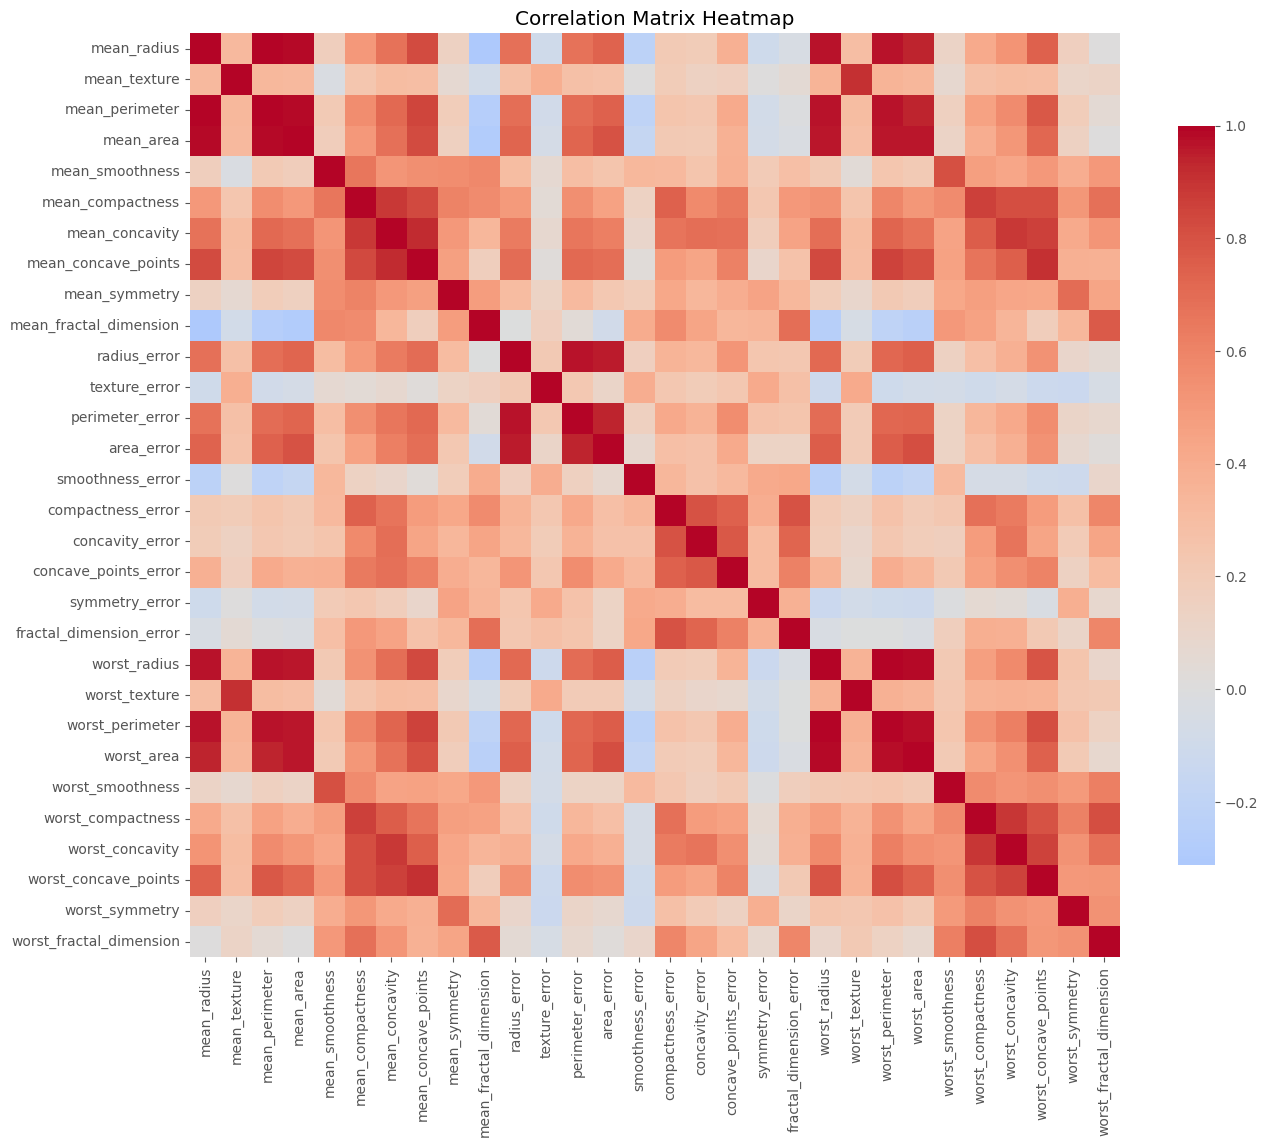

In [22]:
# Since the table is very large, we'll visualize it with a seaborn heatmap.
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0
              , cbar_kws={"shrink": .8})                
plt.title("Correlation Matrix Heatmap")
plt.show()

We can see that there are highly correlated variables. We'll consider variables to be highly correlated when their absolute correlation value is greater than 0.9.

In [30]:
threshold = 0.9

high_corr = (
    corr_matrix.abs()
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
high_corr.columns = ["feature_1", "feature_2", "correlation"]

high_corr[high_corr["correlation"] > threshold].sort_values("correlation", ascending=True).reset_index(drop=True).to_csv('../results/highly_correlated_variables.csv')


The correlation analysis reveals strong redundancy among several groups of features, particularly those related to tumor size (radius, perimeter, area), concavity measures, and their associated error and worst-case variants. Dentro de cada grupo de variables altamente correlacionadas, ¿cuál separa mejor malignant vs benign?

In [24]:
def plot_feature_group(df, features, group_name):
    n = len(features)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=False)
    if n == 1:
        axes = [axes]

    for ax, feature in zip(axes, features):
        sns.boxplot(
            data=df,
            x="diagnosis_label",
            y=feature,
            ax=ax
        )
        ax.set_title(feature)
        ax.set_xlabel("Diagnosis")
        ax.set_ylabel("")

    fig.suptitle(group_name, fontsize=14)
    plt.tight_layout()
    plt.show()

d:\projects\venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\projects\venv\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
d:\projects\venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\projects\venv\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future vers

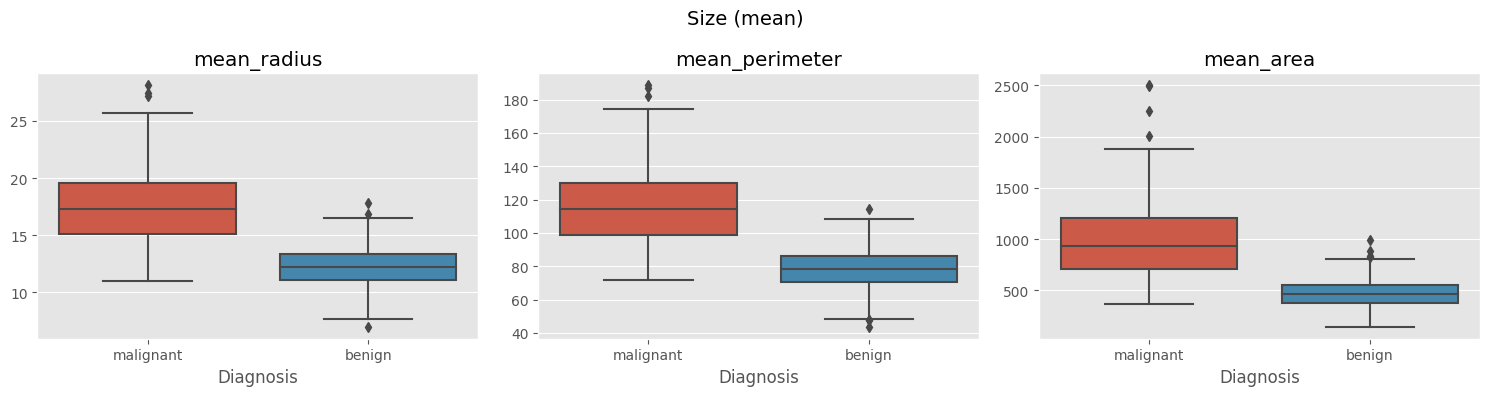

d:\projects\venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\projects\venv\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
d:\projects\venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\projects\venv\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future vers

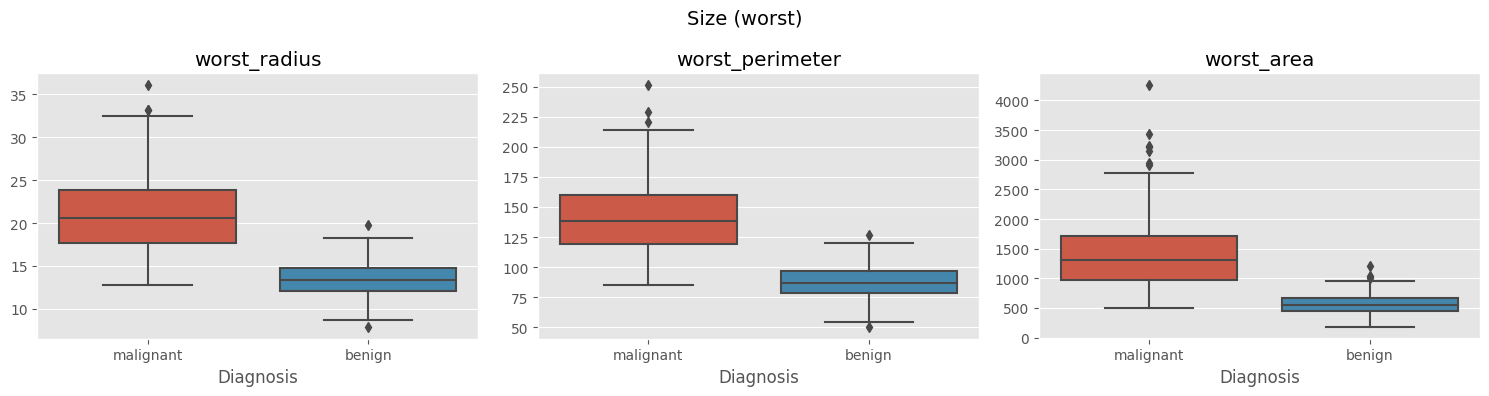

d:\projects\venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\projects\venv\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
d:\projects\venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\projects\venv\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future vers

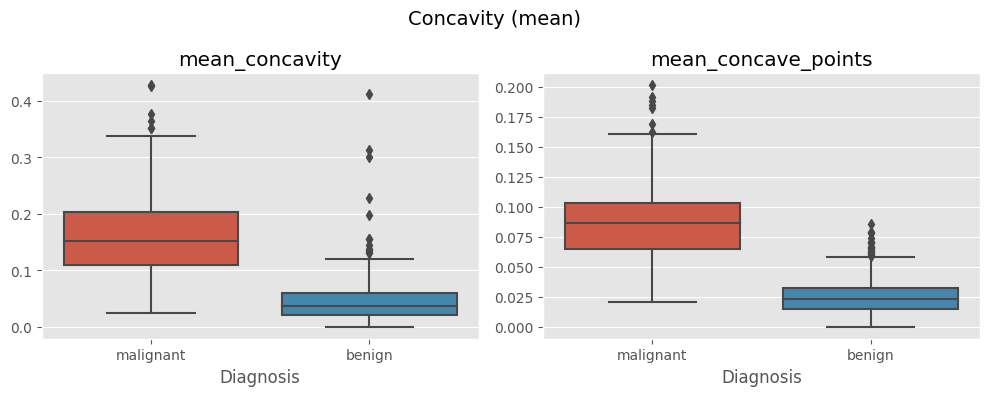

In [25]:
feature_groups = {
    "Size (mean)": ["mean_radius", "mean_perimeter", "mean_area"],
    "Size (worst)": ["worst_radius", "worst_perimeter", "worst_area"],
    "Concavity (mean)": ["mean_concavity", "mean_concave_points"],
}
for group_name, features in feature_groups.items():
    plot_feature_group(renamed_df, features, group_name)

Grouped boxplots comparing representative features across diagnostic classes show consistent separation between malignant and benign samples. Size-related variables (mean and worst) exhibit highly similar discriminative patterns, confirming their redundancy. Among concavity-related features, mean_concave_points presents slightly clearer separation and reduced overlap. Based on these observations, a single representative feature per correlated group could be selected for subsequent modeling.

## Summary of EDA findings

After an initial cleaning and standardization of column names, the dataset consists of 569 observations and 30 numerical features, with no missing values detected. The target variable shows a moderate class imbalance. Boxplot analysis reveals the presence of outliers and heterogeneous variability across features, suggesting differences in scale and distribution. Correlation analysis highlights strong redundancy among several groups of size-related and concavo-convex features. These observations motivate the use of feature scaling and feature selection in subsequent steps.